In [1]:
from networkx.readwrite import json_graph
from scipy.stats import percentileofscore
from traceback import format_exception
import cProfile
import json
import networkx as nx
import numpy as np
import pandas as pd
import pstats
import random
import sys

from Graph import Graph
from PlotUtils import plot_backbone_statistics
from alpha_stats import calc_quantiles

In [5]:
import networkx as nx
random_test=Graph.random(n=500, k=10, seed=42)
#Write it to gephi format 
nx.write_gexf(random_test.G, "random_test.gexf")
random_test.describe_graph(random_test.G, show_centrality=False)



Graph: 500 nodes, 0 edges



In [6]:
from filter import get_backbone
# 2. Extract Backbone
alpha_val = 0.05
backbone_nx = get_backbone(random_test.G, alpha_val)

# 3. WRAP the backbone in your Graph class to use its methods
random_backbone = Graph(backbone_nx)

print(f"\n--- Backbone (alpha={alpha_val}) ---")
# Call the method ON the new object, not the old one
random_backbone.describe_graph()


--- Backbone (alpha=0.05) ---

Graph: 0 nodes, 0 edges



In [7]:
# main.py
from Graph import Graph
from filter import apply_disparity_filter, get_backbone

# 1. Create Graph (Check that edges are created!)
random_test = Graph.random(n=500, k=10, seed=42)
print("--- Original ---")
random_test.describe()  # Should see ~500 nodes and ~2500 edges

# 2. Apply Filter (In-place modification of random_test.G)
apply_disparity_filter(random_test.G)

# 3. Extract Backbone (Returns a NetworkX graph)
alpha_val = 0.05
backbone_nx = get_backbone(random_test.G, alpha_val)

# 4. Wrap Backbone in Graph Class to analyze it
random_backbone = Graph(backbone_nx)

print(f"\n--- Backbone (alpha={alpha_val}) ---")
random_backbone.describe() # Should see ~200-300 nodes and fewer edges

--- Original ---
Graph: 500 nodes, 0 edges

--- Backbone (alpha=0.05) ---
Graph: 0 nodes, 0 edges


AttributeError: 'Graph' object has no attribute 'edges'

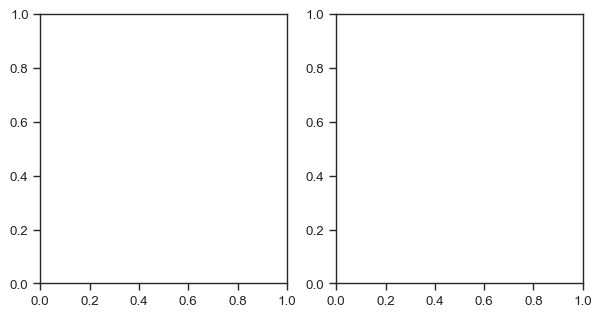

In [ ]:
from PlotUtils import plot_backbone_statistics
    
plot_backbone_statistics(random_test,random_backbone, directed=False)  # Ejemplo de uso

In [ ]:
scale_free_test=Graph.scale_free(n=500, seed=42)
scale_free_test.describe_graph(scale_free_test.G, show_centrality=False)


Graph: 500 nodes 996 edges



In [ ]:
apply_disparity_filter(scale_free_test.G)

# 3. Extract Backbone for a specific significance level
# The paper suggests optimal alpha often in range [0.01, 0.5] [cite: 247]
alpha_val = 0.05
backbone = get_backbone(scale_free_test.G, alpha_val)
scale_free_test.describe_graph(backbone, show_centrality=False)


Graph: 500 nodes 996 edges



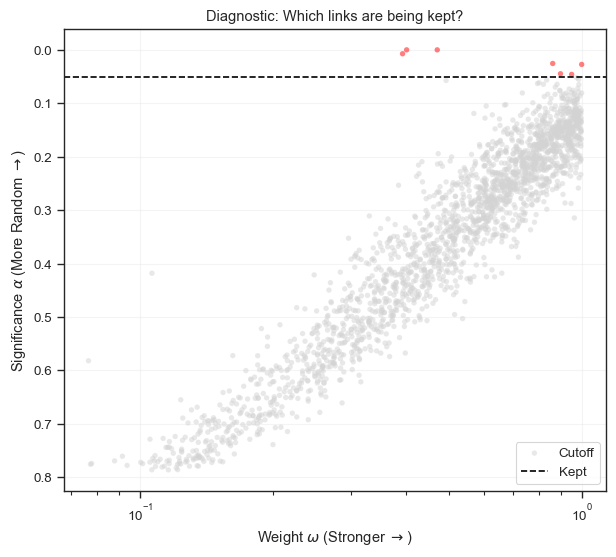

In [ ]:
from PlotUtils import plot_alpha_vs_weight

plot_alpha_vs_weight(graph, alpha_cutoff=0.05)